In [1]:
import pandas as pd
import matplotsoccer
import numpy as np
from tqdm.notebook import tqdm


In [2]:
df = pd.read_csv("../../converter/data/ESP-La Liga/2024-2025/1821431.csv") 

In [3]:
df.head()

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,end_x,start_y,end_y,type_id,result_id,bodypart_id,action_id,type_name,result_name,bodypart_name
0,1821431,2.710745e+09,1,0.0,51,106596.0,52.500,30.450,34.000,28.016,0,1,0,0,pass,success,foot
1,1821431,2.710745e+09,1,3.0,51,142387.0,30.450,60.795,28.016,68.000,0,0,0,1,pass,fail,foot
2,1821431,2.710745e+09,1,18.0,52,106883.0,60.375,58.695,68.000,64.464,2,1,2,2,throw_in,success,other
3,1821431,2.710745e+09,1,19.0,52,344644.0,58.695,61.845,64.464,66.776,0,0,0,3,pass,fail,foot
4,1821431,2.710745e+09,1,20.0,51,6227.0,63.210,70.980,64.804,60.520,0,1,0,4,pass,success,foot


In [4]:
def plot_actions(df_actions_to_plot):
    matplotsoccer.actions(
        location=df_actions_to_plot[['start_x', 'start_y', 'end_x', 'end_y']],
        action_type=df_actions_to_plot['type_name'],
        result=df_actions_to_plot['result_name'] == 'success',
        zoom=False,
        figsize=8)


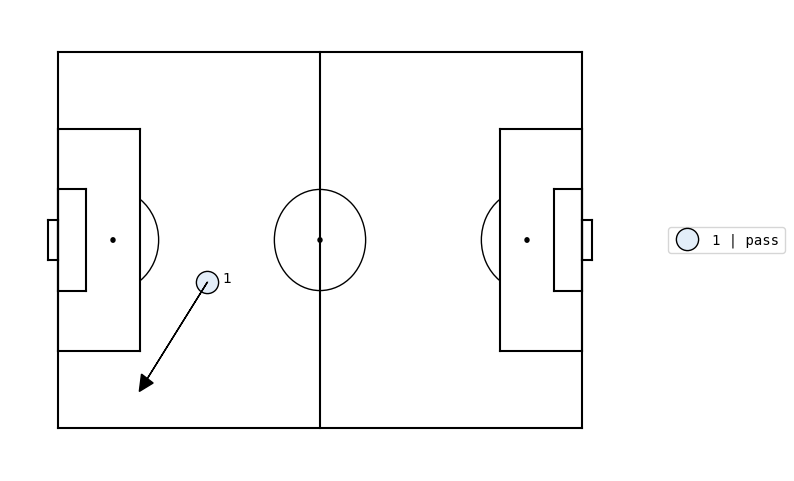

In [5]:
action_id = 145
plot_actions(df[action_id:action_id + 1])

In [6]:
l = df.columns


In [7]:
type(l)

pandas.core.indexes.base.Index

In [8]:
l = l.to_list()

In [9]:
l

['game_id',
 'original_event_id',
 'period_id',
 'time_seconds',
 'team_id',
 'player_id',
 'start_x',
 'end_x',
 'start_y',
 'end_y',
 'type_id',
 'result_id',
 'bodypart_id',
 'action_id',
 'type_name',
 'result_name',
 'bodypart_name']

In [10]:
import socceraction.vaep.features as fs

In [11]:
xfns = [
    fs.actiontype,
    fs.actiontype_onehot,
    fs.bodypart,
    fs.bodypart_onehot,
    fs.result,
    fs.result_onehot,
    fs.goalscore,
    fs.startlocation,
    fs.endlocation,
    fs.movement,
    fs.space_delta,
    fs.startpolar,
    fs.endpolar,
    fs.team,
    fs.time,
    fs.time_delta
]

In [12]:
import pandas as pd
import socceraction.vaep.features as fs
import socceraction.vaep.labels as lab

In [13]:
unique_teams = df['team_id'].unique()

In [14]:
home_team_id = unique_teams[0]

In [15]:
yfns = [
    lab.scores,
    lab.concedes
]

In [16]:
gamestates = fs.gamestates(df, nb_prev_actions=3)
gamestates = fs.play_left_to_right(gamestates, home_team_id)

/home/esalama01/projects/uSoccer/.venv/lib/python3.12/site-packages/socceraction/vaep/features.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_actions = actions.groupby(["game_id", "period_id"], sort=False, as_index=False).apply(
/home/esalama01/projects/uSoccer/.venv/lib/python3.12/site-packages/socceraction/vaep/features.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_actions = actions.groupby([

In [17]:
X = pd.concat([fn(gamestates) for fn in xfns], axis=1)

In [18]:
Y = pd.concat([fn(df) for fn in yfns], axis=1)

In [19]:
X.shape

(1716, 163)

In [20]:
Y.shape

(1716, 2)

In [21]:
df1 = pd.read_csv("../../converter/data/ESP-La Liga/2024-2025/1821431.csv")

In [22]:
df1.shape

(1716, 17)

In [23]:
df1.head(1)

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,end_x,start_y,end_y,type_id,result_id,bodypart_id,action_id,type_name,result_name,bodypart_name
0,1821431,2.710745e+09,1,0.0,51,106596.0,52.5,30.45,34.0,28.016,0,1,0,0,pass,success,foot


In [24]:
X.head(1)

,actiontype_a0,actiontype_a1,actiontype_a2,actiontype_pass_a0,actiontype_cross_a0,actiontype_throw_in_a0,actiontype_freekick_crossed_a0,actiontype_freekick_short_a0,actiontype_corner_crossed_a0,actiontype_corner_short_a0,...,time_seconds_a0,time_seconds_overall_a0,period_id_a1,time_seconds_a1,time_seconds_overall_a1,period_id_a2,time_seconds_a2,time_seconds_overall_a2,time_delta_1,time_delta_2
0,pass,pass,pass,True,False,False,False,False,False,False,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [25]:
X.columns

Index(['actiontype_a0', 'actiontype_a1', 'actiontype_a2', 'actiontype_pass_a0',
       'actiontype_cross_a0', 'actiontype_throw_in_a0',
       'actiontype_freekick_crossed_a0', 'actiontype_freekick_short_a0',
       'actiontype_corner_crossed_a0', 'actiontype_corner_short_a0',
       ...
       'time_seconds_a0', 'time_seconds_overall_a0', 'period_id_a1',
       'time_seconds_a1', 'time_seconds_overall_a1', 'period_id_a2',
       'time_seconds_a2', 'time_seconds_overall_a2', 'time_delta_1',
       'time_delta_2'],
      dtype='object', length=163)

In [26]:
xfns[6](gamestates)

,goalscore_team,goalscore_opponent,goalscore_diff
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
1711,1,1,0
1712,1,1,0
1713,1,1,0
1714,1,1,0


In [27]:
full = pd.concat([X,Y], axis = 1)

In [28]:
full.shape

(1716, 165)

In [29]:
X.shape

(1716, 163)